In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn import linear_model

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

#  Fig. 1

In [3]:
SW2_df = pd.read_csv('./results/2020_S/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [4]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']

In [5]:
SW2_df = SW2_df.interpolate()
SW2_df.index = SW2_df.index.round(freq='1 d') 
SW2_df = SW2_df.groupby(SW2_df.index).mean()

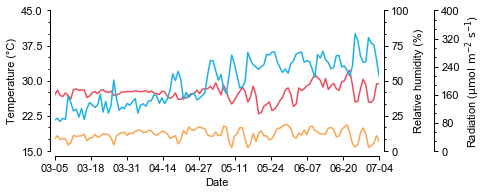

In [6]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['temp'], c=cmap[0], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['hum'], c=cmap[4], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['rad'], c=cmap[2], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(15, 45)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(0, 400)

ax0.set_xlabel('Date')
ax0.set_ylabel('Temperature (°C)')
ax1.set_ylabel('Relative humidity (%)')
ax2.set_ylabel('Radiation (${\mu}mol{\ }m^{-2}{\ }s^{-1}$)')

fig.tight_layout()
fig.savefig('./figures/Fig1-1.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

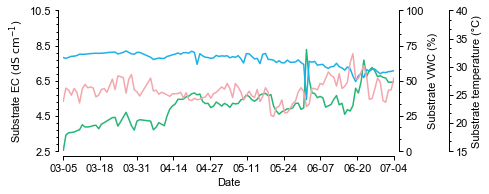

In [7]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.plot(SW2_df.index, SW2_df['subs_EC'], c=cmap[3], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[4], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['subs_temp'], c=cmap_m[0], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(21))
ax0.set_ybound(2.5, 10.5)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(15, 40)

ax0.set_xlabel('Date')
ax0.set_ylabel('Substrate EC ($dS{\ }cm^{-1}$)')
ax1.set_ylabel('Substrate VWC (%)')
ax2.set_ylabel('Substrate temperature (°C)')

fig.tight_layout()
fig.savefig('./figures/Fig1-2.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

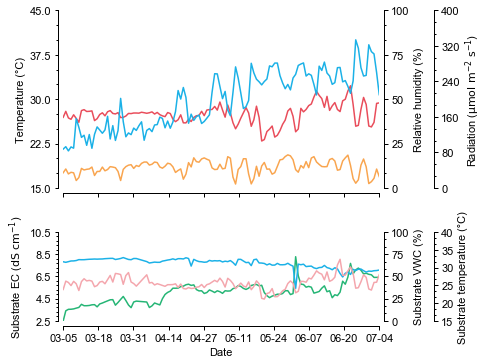

In [8]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*2.2)))
grid = plt.GridSpec(2, 1, height_ratios=[2, 1])

ax0 = plt.subplot(grid[0])

ax0.plot(SW2_df.index, SW2_df['temp'], c=cmap[0], zorder=3)

ax1 = ax0.twinx()
ax1.plot(SW2_df.index, SW2_df['hum'], c=cmap[4], zorder=2)

ax2 = ax0.twinx()
ax2.plot(SW2_df.index, SW2_df['rad'], c=cmap[2], zorder=1)

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.axes.xaxis.set_ticklabels([])

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(15, 45)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(0, 400)

ax0.set_ylabel('Temperature (°C)')
ax1.set_ylabel('Relative humidity (%)')
ax2.set_ylabel('Radiation (${\mu}mol{\ }m^{-2}{\ }s^{-1}$)')



ax3 = plt.subplot(grid[1])

ax3.plot(SW2_df.index, SW2_df['subs_EC'], c=cmap[3], zorder=3)

ax4 = ax3.twinx()
ax4.plot(SW2_df.index, SW2_df['subs_VWC'], c=cmap[4], zorder=2)

ax5 = ax3.twinx()
ax5.plot(SW2_df.index, SW2_df['subs_temp'], c=cmap_m[0], zorder=1)

ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 5))
ax3.spines['bottom'].set_position(('outward', 5))
ax4.spines['left'].set_visible(False)
ax4.spines['right'].set_position(('outward', 5))
ax4.spines['bottom'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.spines['right'].set_position(('outward', 55))
ax5.spines['bottom'].set_visible(False)

ax3.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax3.xaxis.set_major_locator(LinearLocator(10))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax3.yaxis.set_major_locator(LinearLocator(5))
ax3.yaxis.set_minor_locator(LinearLocator(21))
ax3.set_ybound(2.5, 10.5)
ax4.yaxis.set_major_locator(LinearLocator(5))
ax4.yaxis.set_minor_locator(LinearLocator(13))
ax4.set_ybound(0, 100)
ax5.yaxis.set_major_locator(LinearLocator(6))
ax5.yaxis.set_minor_locator(LinearLocator(16))
ax5.set_ybound(15, 40)

ax3.set_xlabel('Date')
ax3.set_ylabel('Substrate EC ($dS{\ }cm^{-1}$)')
ax4.set_ylabel('Substrate VWC (%)')
ax5.set_ylabel('Substrate temperature (°C)')

fig.tight_layout()
fig.savefig('./figures/Fig1.svg', transparent=True, format='svg')
#fig.savefig('./figures/Fig1-1.png', transparent=True, dpi=600, format='png')
plt.show() 

#  Fig. 2

In [9]:
SW2_df = pd.read_csv('./results/2020_S/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [10]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']
SW2_df = SW2_df

In [11]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*4)/1000
rockwool_mean = rockwool.mean()

In [12]:
substrate_volume = (120*12*7.5 + 10*10*6.5*4)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [13]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - rockwool_mean
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - rockwool_mean
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - rockwool_mean

In [14]:
weight_df = pd.read_csv('./results/2020_S/weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
weight_df.index = np.append(weight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [15]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [16]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

In [17]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

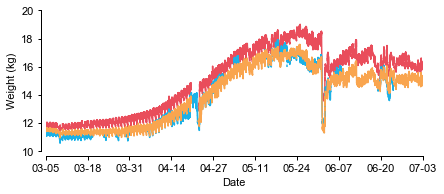

In [18]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_2'], c=cmap[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3'], c=cmap[4])
ax0.plot(SW2_df.index, SW2_df['loadcell_1'], c=cmap[2])

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.set_ybound(10, 20)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig2.svg', transparent=True, format='svg')
plt.show()

#  Fig. 3

In [19]:
weight_df = pd.read_csv('./results/2020_S/weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
weight_df.index = np.append(weight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [20]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [21]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

In [22]:
wweight_wr_df = wweight_wr_df/1000
fw_df = wweight_wr_df.groupby(wweight_wr_df.index).mean()
fw_er_df = wweight_wr_df.groupby(wweight_wr_df.index).std()

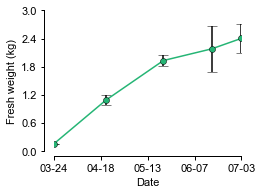

In [23]:
fig = plt.figure(figsize=((8/2.54*1.2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(fw_df.index, fw_df, yerr=fw_er_df, marker='o', capthick=2, capsize=5, ecolor='k', c=cmap[3], mec='k', mew=0.5)

ax0.set_xbound(fw_df.index.min(), fw_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(5))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.set_ybound(0, 3)

ax0.set_xlabel('Date')
ax0.set_ylabel('Fresh weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig3.svg', transparent=True, format='svg')
plt.show()

#  Fig. 4

In [24]:
SW2_df = pd.read_csv('./results/2020_S/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [25]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']
SW2_df = SW2_df

In [26]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*4)/1000
rockwool_mean = rockwool.mean()

In [27]:
substrate_volume = (120*12*7.5 + 10*10*6.5*4)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [28]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - rockwool_mean
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - rockwool_mean
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - rockwool_mean

In [29]:
weight_df = pd.read_csv('./results/2020_S/weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
weight_df.index = np.append(weight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [30]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [31]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

In [32]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

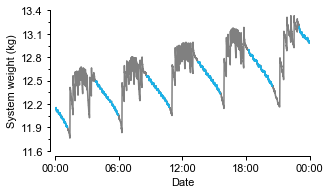

In [33]:
fig = plt.figure(figsize=((8/2.54*1.5), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_1'], '-', c='gray')
ax0.plot(SW2_df.index, night_df.reindex(SW2_df.index)['loadcell_1'], '-', c=cmap[4])

ax0.set_xbound(pd.Timestamp('2020-04-13 00:00:00'), pd.Timestamp('2020-04-18 00:00:00'))
ax0.xaxis.set_major_locator(LinearLocator(5))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(11.6, 13.4)

ax0.set_xlabel('Date')
ax0.set_ylabel('System weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig4.svg', transparent=True, format='svg')
plt.show()

#  Fig. 5

In [34]:
VWC_df = SW2_df['subs_VWC'].resample('H').mean()

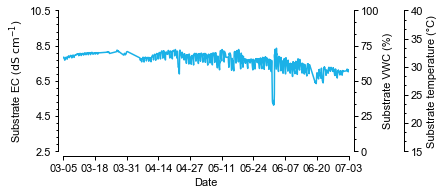

In [35]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax1 = ax0.twinx()
ax1.plot(VWC_df.index, VWC_df.interpolate(), '-', c=cmap[4], mew=1.5, mfc='w', zorder=2)

ax2 = ax0.twinx()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['left'].set_visible(False)
ax1.spines['right'].set_position(('outward', 5))
ax1.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_position(('outward', 55))
ax2.spines['bottom'].set_visible(False)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.yaxis.set_minor_locator(LinearLocator(21))
ax0.set_ybound(2.5, 10.5)
ax1.yaxis.set_major_locator(LinearLocator(5))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_ybound(0, 100)
ax2.yaxis.set_major_locator(LinearLocator(6))
ax2.yaxis.set_minor_locator(LinearLocator(16))
ax2.set_ybound(15, 40)

ax0.set_xlabel('Date')
ax0.set_ylabel('Substrate EC ($dS{\ }cm^{-1}$)')
ax1.set_ylabel('Substrate VWC (%)')
ax2.set_ylabel('Substrate temperature (°C)')

fig.tight_layout()
fig.savefig('./figures/Fig5.svg', transparent=True, format='svg')
plt.show() 

#  Fig. 6

In [36]:
SW2_df = pd.read_csv('./results/2020_S/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [37]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']
SW2_df = SW2_df.interpolate()

In [38]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*4)/1000
rockwool_mean = rockwool.mean()

In [39]:
substrate_volume = (120*12*7.5 + 10*10*6.5*4)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [40]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - rockwool_mean
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - rockwool_mean
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - rockwool_mean

In [41]:
weight_df = pd.read_csv('./results/2020_S/weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
weight_df.index = np.append(weight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [42]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [43]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

### Excepting irrigation disturbance

In [44]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

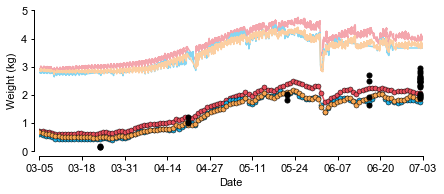

In [45]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(SW2_df.index, SW2_df['loadcell_2']/4, c=cmap_m[0])
ax0.plot(SW2_df.index, SW2_df['loadcell_3']/4, c=cmap_m[4])
ax0.plot(SW2_df.index, SW2_df['loadcell_1']/4, c=cmap_m[2])

ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_2'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[0])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_3'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[4])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_1'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[2])

ax0.plot(wweight_df.index, wweight_wr_df/1000, 'o', ms=5, c='k')

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.set_ybound(0, 5)

ax0.set_xlabel('Date')
ax0.set_ylabel('Weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig6.svg', transparent=True, format='svg')
plt.show()

#  Fig. 7

In [46]:
pg_df = []
pg_er_df = []

In [47]:
temp_df = pd.read_csv('./results/2020_S/node_length.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)
temp_df.iloc[4, 2] = np.nan
temp_df.iloc[3, 3] -= 3
temp_er_df = temp_df.std(axis=1)
temp_df = temp_df.mean(axis=1)

pg_df.append(temp_df)
pg_er_df.append(temp_er_df)

In [48]:
temp_df = pd.read_csv('./results/2020_S/node_diameter.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)
temp_df.iloc[4, -2] = np.nan
temp_df.iloc[4, -6] = np.nan
temp_er_df = temp_df.std(axis=1)
temp_df = temp_df.mean(axis=1)

pg_df.append(temp_df)
pg_er_df.append(temp_er_df)

In [49]:
temp_df = pd.read_csv('./results/2020_S/plant_height.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)
temp_er_df = temp_df.std(axis=1)
temp_df = temp_df.mean(axis=1)

pg_df.append(temp_df)
pg_er_df.append(temp_er_df)

In [50]:
temp_df = pd.read_csv('./results/2020_S/leaf_area.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])/10000
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)
temp_er_df = temp_df.std(axis=1)
temp_df = temp_df.mean(axis=1)

pg_df.append(temp_df)
pg_er_df.append(temp_er_df)

In [51]:
pg_df = pd.concat(pg_df, axis=1)
pg_df.columns = ['node_len', 'node_dia', 'plant_h', 'leaf_area']

In [52]:
pg_er_df = pd.concat(pg_er_df, axis=1)
pg_er_df.columns = ['node_len', 'node_dia', 'plant_h', 'leaf_area']

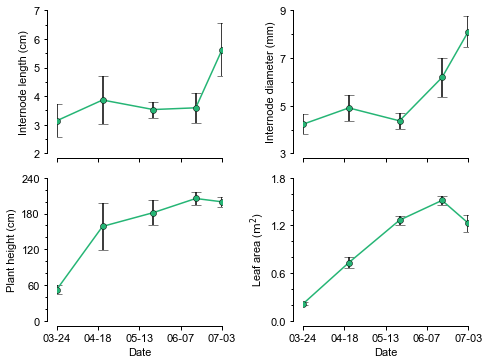

In [53]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*2.2)))
grid = plt.GridSpec(2, 2)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.errorbar(pg_df.index, pg_df['node_len'], yerr=pg_er_df['node_len'], marker='o', capthick=2, capsize=5, ecolor='k', c=cmap[3], mec='k', mew=0.5)
ax1.errorbar(pg_df.index, pg_df['node_dia'], yerr=pg_er_df['node_dia'], marker='o', capthick=2, capsize=5, ecolor='k', c=cmap[3], mec='k', mew=0.5)
ax2.errorbar(pg_df.index, pg_df['plant_h'], yerr=pg_er_df['plant_h'], marker='o', capthick=2, capsize=5, ecolor='k', c=cmap[3], mec='k', mew=0.5)
ax3.errorbar(pg_df.index, pg_df['leaf_area'], yerr=pg_er_df['leaf_area'], marker='o', capthick=2, capsize=5, ecolor='k', c=cmap[3], mec='k', mew=0.5)

ax0.set_xbound(pg_df.index.min(), pg_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(5))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(2, 7)
ax1.set_xbound(pg_df.index.min(), pg_df.index.max())
ax1.xaxis.set_major_locator(LinearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.yaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_minor_locator(LinearLocator(7))
ax1.set_ybound(3, 9)
ax2.set_xbound(pg_df.index.min(), pg_df.index.max())
ax2.xaxis.set_major_locator(LinearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.yaxis.set_major_locator(LinearLocator(5))
ax2.yaxis.set_minor_locator(LinearLocator(13))
ax2.set_ybound(0, 240)
ax3.set_xbound(pg_df.index.min(), pg_df.index.max())
ax3.xaxis.set_major_locator(LinearLocator(5))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax3.yaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_minor_locator(LinearLocator(10))
ax3.set_ybound(0, 1.8)

ax0.axes.xaxis.set_ticklabels([])
ax1.axes.xaxis.set_ticklabels([])

ax0.set_ylabel('Internode length (cm)')
ax1.set_ylabel('Internode diameter (mm)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Plant height (cm)')
ax3.set_xlabel('Date')
ax3.set_ylabel('Leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig7.svg', transparent=True, format='svg')
plt.show()

#  Fig. 8

In [54]:
pg_df = []

In [55]:
temp_df = pd.read_csv('./results/2020_S/node_length.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['node_len'])

pg_df.append(temp_df)

In [56]:
temp_df = pd.read_csv('./results/2020_S/node_diameter.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['node_dia'])

pg_df.append(temp_df)

In [57]:
temp_df = pd.read_csv('./results/2020_S/plant_height.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['plant_h'])

pg_df.append(temp_df)

In [58]:
temp_df = pd.read_csv('./results/2020_S/leaf_area.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

last_day = pd.concat([temp_df.loc['2020-07-07'].dropna(),
                      temp_df.loc['2020-07-08'].dropna(),
                      temp_df.loc['2020-07-09'].dropna()]).reset_index().drop('index', axis=1)
last_day.index = list(last_day.index)

temp_index = temp_df.index
temp_df = pd.concat([temp_df.loc[:'2020-06-17'], last_day.T])/10000
temp_df.index = list(temp_index[:-3]) + ['2020-07-03']
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['leaf_area'])

pg_df.append(temp_df)

In [59]:
pg_df = pd.concat(pg_df, axis=1)
pg_df['DAT'] = [27]*3 + [55]*3 + [86]*3 + [112]*4 + [128]*20
pg_df['date'] = pg_df.index
pg_df = pg_df.set_index(['DAT'])

In [60]:
pg_reg_df = []
plot_x = [_ for _ in range(27, 129)]

In [61]:
def sigmoid(x, L, k, x0, b):
    return L / (b + np.exp(-k*(x-x0)))

In [62]:
pg_df.iloc[-18, 0] = np.nan
pg_df.iloc[-2, 1] = np.nan
pg_df.iloc[-6, 1] = np.nan
pg_df.iloc[-21, 0] -= 3
pg_df = pg_df.dropna()

In [63]:
x = pg_df.index
y = pg_df['node_len']
polreg = np.poly1d(np.polyfit(x,y,3))
print(r2_score(y, polreg(x)))

plot_y = polreg(plot_x)
pg_reg_df.append(plot_y)

0.7185346190241422


In [64]:
x = pg_df.index
y = pg_df['node_dia']
polreg = np.poly1d(np.polyfit(x,y,3))
print(r2_score(y, polreg(x)))

plot_y = polreg(plot_x)
pg_reg_df.append(plot_y)

0.8822503506478436


In [65]:
x = pg_df.index
y = pg_df['plant_h']
popt, pcov = curve_fit(sigmoid, x, y, method='trf')
print(r2_score(y, sigmoid(x, *popt)))

plot_y = sigmoid(plot_x, *popt)
pg_reg_df.append(plot_y)

0.9037982257172344


In [66]:
x = pg_df.index
y = pg_df['leaf_area']*1000
popt, pcov = curve_fit(sigmoid, x, y, method='trf')
print(r2_score(y, sigmoid(x, *popt)))

plot_y = sigmoid(plot_x, *popt)
pg_reg_df.append(plot_y/1000)

0.8882709607841659


In [67]:
pg_reg_df = pd.DataFrame(pg_reg_df).T
pg_reg_df.columns = ['node_len', 'node_dia', 'plant_h', 'leaf_area']

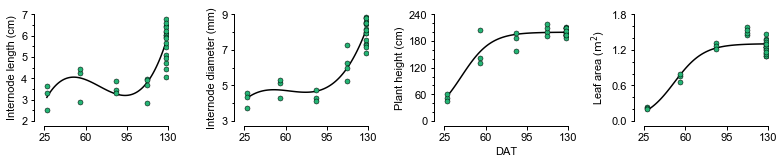

In [68]:
fig = plt.figure(figsize=((8/2.54*3.5), (6/2.54*1)))
grid = plt.GridSpec(1, 4)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(plot_x, pg_reg_df['node_len'], '-', ms=5, c='k')
ax0.plot(pg_df.index, pg_df['node_len'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax1.plot(plot_x, pg_reg_df['node_dia'], '-', ms=5, c='k')
ax1.plot(pg_df.index, pg_df['node_dia'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax2.plot(plot_x, pg_reg_df['plant_h'], '-', ms=5, c='k')
ax2.plot(pg_df.index, pg_df['plant_h'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax3.plot(plot_x, pg_reg_df['leaf_area'], '-', ms=5, c='k')
ax3.plot(pg_df.index, pg_df['leaf_area'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])

ax0.set_xbound(25, 130)
ax0.xaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(2, 7)
ax1.set_xbound(25, 130)
ax1.xaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_minor_locator(LinearLocator(7))
ax1.set_ybound(3, 9)
ax2.set_xbound(25, 130)
ax2.xaxis.set_major_locator(LinearLocator(4))
ax2.yaxis.set_major_locator(LinearLocator(5))
ax2.yaxis.set_minor_locator(LinearLocator(13))
ax2.set_ybound(0, 240)
ax3.set_xbound(25, 130)
ax3.xaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_minor_locator(LinearLocator(10))
ax3.set_ybound(0, 1.8)

ax0.set_ylabel('Internode length (cm)')
ax1.set_ylabel('Internode diameter (mm)')
ax2.set_xlabel('DAT')
ax2.set_ylabel('Plant height (cm)')
ax3.set_ylabel('Leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig8.svg', transparent=True, format='svg')
plt.show()

#  Fig. 8-2

In [69]:
pg_df = []

In [70]:
temp_df = pd.read_csv('./results/2020_W/node_length.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

temp_index = temp_df.index
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['node_len'])

pg_df.append(temp_df)

In [71]:
temp_df = pd.read_csv('./results/2020_W/node_diameter.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

temp_index = temp_df.index
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['node_dia'])

pg_df.append(temp_df)

In [72]:
temp_df = pd.read_csv('./results/2020_W/plant_height.csv', index_col='Unnamed: 0')
temp_df.columns = temp_df.columns.astype('int64')

temp_index = temp_df.index
temp_df.index = pd.DatetimeIndex(temp_df.index)

l = []
l_i = []
for _ in range(temp_df.shape[0]):
    ll = temp_df.iloc[_].dropna()
    l.extend(ll.values)
    l_i.extend([temp_df.index[_]]*ll.shape[0])
temp_df = pd.DataFrame(l, index=l_i, columns=['plant_h'])

pg_df.append(temp_df)

In [73]:
temp_df = pd.read_csv('./results/2020_W/leaf_area.csv', index_col='Unnamed: 0')/10000
temp_index = temp_df.index
temp_df.index = pd.DatetimeIndex(temp_df.index)
pg_df.append(temp_df)

In [74]:
pg_df = pd.concat(pg_df, axis=1)
pg_df['DAT'] = [15]*3 + [50]*6 + [80]*6 + [108]*3 + [153]*15
pg_df['date'] = pg_df.index
pg_df = pg_df.set_index(['DAT'])

In [75]:
pg_reg_df = []
plot_x = [_ for _ in range(10, 155)]
date_x = pd.date_range('2020-09-04', '2021-01-26', freq='1d')

In [76]:
pg_df.iloc[1, 1] -= 4
pg_df.loc[80, 'leaf_area'] -= 0.2
pg_df.iloc[-6, 0] += 3

In [77]:
def sigmoid(x, L, k, x0, b):
    return L / (b + np.exp(-k*(x-x0)))

In [78]:
x = pg_df.index
y = pg_df['node_len']
polreg = np.poly1d(np.polyfit(x,y,3))
print(r2_score(y, polreg(x)))

plot_y = polreg(plot_x)
pg_reg_df.append(plot_y)

0.6441371042982342


In [79]:
x = pg_df.index
y = pg_df['node_dia']
polreg = np.poly1d(np.polyfit(x,y,3))
print(r2_score(y, polreg(x)))

plot_y = polreg(plot_x)
pg_reg_df.append(plot_y)

0.7505525386320662


In [80]:
x = pg_df.index
y = pg_df['plant_h']
popt, pcov = curve_fit(sigmoid, x, y, method='trf')
print(r2_score(y, sigmoid(x, *popt)))

plot_y = sigmoid(plot_x, *popt)
pg_reg_df.append(plot_y)

0.8865414461942855


In [81]:
# x = pg_df.index
# y = pg_df['leaf_area']
# xMAX = x.max()
# xMIN = x.min()
# yMAX = pg_df['leaf_area'].max()
# yMIN = pg_df['leaf_area'].min()
# x = (x - xMIN)/(xMAX - xMIN)
# y = (y - yMIN)/(yMAX - yMIN)
# popt, pcov = curve_fit(sigmoid, x, y, method='trf')
# print(r2_score(y, sigmoid(x, *popt)))

# plot_y = sigmoid((plot_x - xMIN)/(xMAX - xMIN), *popt)
# pg_reg_df.append(plot_y*(yMAX - yMIN) + yMIN)

In [82]:
x = pg_df.index
y = pg_df['leaf_area']*1000
popt, pcov = curve_fit(sigmoid, x, y, method='trf')
print(r2_score(y, sigmoid(x, *popt)))

plot_y = sigmoid(plot_x, *popt)
pg_reg_df.append(plot_y/1000)

0.9060999514258448


In [83]:
pg_reg_df = pd.DataFrame(pg_reg_df).T
pg_reg_df.columns = ['node_len', 'node_dia', 'plant_h', 'leaf_area']

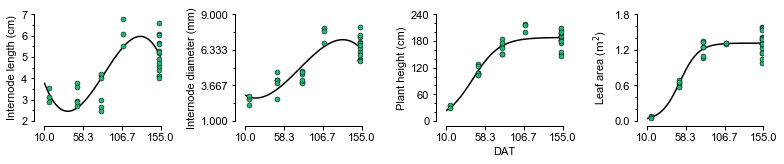

In [84]:
fig = plt.figure(figsize=((8/2.54*3.5), (6/2.54*1)))
grid = plt.GridSpec(1, 4)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(plot_x, pg_reg_df['node_len'], '-', ms=5, c='k')
ax0.plot(pg_df.index, pg_df['node_len'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax1.plot(plot_x, pg_reg_df['node_dia'], '-', ms=5, c='k')
ax1.plot(pg_df.index, pg_df['node_dia'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax2.plot(plot_x, pg_reg_df['plant_h'], '-', ms=5, c='k')
ax2.plot(pg_df.index, pg_df['plant_h'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])
ax3.plot(plot_x, pg_reg_df['leaf_area'], '-', ms=5, c='k')
ax3.plot(pg_df.index, pg_df['leaf_area'], 'o', ms=5, mew=0.5, mec='k', c=cmap[3])

ax0.set_xbound(10, 155)
ax0.xaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
ax0.set_ybound(2, 7)
ax1.set_xbound(10, 155)
ax1.xaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_minor_locator(LinearLocator(7))
ax1.set_ybound(1, 9)
ax2.set_xbound(10, 155)
ax2.xaxis.set_major_locator(LinearLocator(4))
ax2.yaxis.set_major_locator(LinearLocator(5))
ax2.yaxis.set_minor_locator(LinearLocator(13))
ax2.set_ybound(0, 240)
ax3.set_xbound(10, 155)
ax3.xaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_minor_locator(LinearLocator(10))
ax3.set_ybound(0, 1.8)

ax0.set_ylabel('Internode length (cm)')
ax1.set_ylabel('Internode diameter (mm)')
ax2.set_xlabel('DAT')
ax2.set_ylabel('Plant height (cm)')
ax3.set_ylabel('Leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig8-2.svg', transparent=True, format='svg')
plt.show()

#  Fig. 9

In [85]:
pg_pred_df = pd.read_csv('./results/model_output/pg_pred_result.csv', index_col='Unnamed: 0')

In [86]:
x_linear = [np.arange(100, 600)/100,
            np.arange(300, 900)/100,
            np.arange(0, 240),
            np.arange(0, 1600)/100,
           ]
y_linear = x_linear

In [87]:
regr = linear_model.LinearRegression()
reg_df = []
for _ in range(4):
    regr.fit(pg_pred_df.iloc[:, _].values.reshape(-1,1), pg_pred_df.iloc[:, _+4].values.reshape(-1,1))
    Yp = regr.predict(pg_pred_df.iloc[:, _].values.reshape(-1,1))
    reg_y = x_linear[_]*regr.coef_ + regr.intercept_
    reg_df.append(reg_y[0])
reg_df = np.array(reg_df).T

In [88]:
for _ in range(4):
    print(r2_score(pg_pred_df.iloc[:, _].values.reshape(-1,1), pg_pred_df.iloc[:, _+4].values.reshape(-1,1)))

0.9537512699222713
0.9859775927416742
0.9866817989782222
0.991150886917597


In [89]:
pg_tr_df = pd.read_csv('./results/model_output/pg_transfer_pred_result.csv', index_col='Unnamed: 0')

In [90]:
x_linear = [np.arange(100, 600)/100,
            np.arange(300, 900)/100,
            np.arange(0, 240),
            np.arange(0, 1600)/100,
           ]
y_linear = x_linear

In [91]:
regr = linear_model.LinearRegression()
reg_df = []
for _ in range(4):
    regr.fit(pg_tr_df.iloc[:, _].values.reshape(-1,1), pg_tr_df.iloc[:, _+4].values.reshape(-1,1))
    Yp = regr.predict(pg_tr_df.iloc[:, _].values.reshape(-1,1))
    reg_y = x_linear[_]*regr.coef_ + regr.intercept_
    reg_df.append(reg_y[0])
tr_reg_df = np.array(reg_df).T

In [92]:
for _ in range(4):
    print(r2_score(pg_tr_df.iloc[:, _].values.reshape(-1,1), pg_tr_df.iloc[:, _+4].values.reshape(-1,1)))

-1.5024967988114328
0.3668458390526551
0.8268813716434655
0.7051977535633684


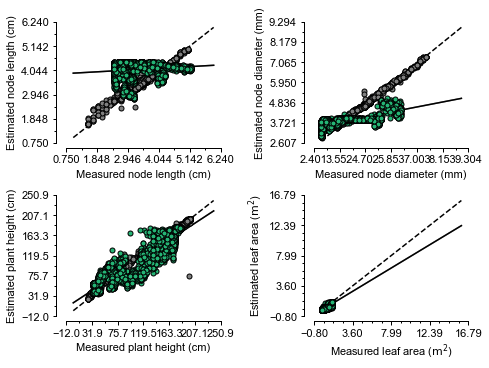

In [95]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*2.2)))
grid = plt.GridSpec(2, 2)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(x_linear[0], y_linear[0], '--', c='k')
ax1.plot(x_linear[1], y_linear[1], '--', c='k')
ax2.plot(x_linear[2], y_linear[2], '--', c='k')
ax3.plot(x_linear[3], y_linear[3], '--', c='k')

ax0.plot(x_linear[0], reg_df[0], '-', c='gray')
ax1.plot(x_linear[1], reg_df[1], '-', c='gray')
ax2.plot(x_linear[2], reg_df[2], '-', c='gray')
ax3.plot(x_linear[3], reg_df[3], '-', c='gray')

ax0.plot(x_linear[0], tr_reg_df[0], '-', c='k')
ax1.plot(x_linear[1], tr_reg_df[1], '-', c='k')
ax2.plot(x_linear[2], tr_reg_df[2], '-', c='k')
ax3.plot(x_linear[3], tr_reg_df[3], '-', c='k')

ax0.plot(pg_pred_df['label_node_len'], pg_pred_df['pred_node_len'], 'o', ms=5, mec='k', c='gray')
ax1.plot(pg_pred_df['label_node_dia'], pg_pred_df['pred_node_dia'], 'o', ms=5, mec='k', c='gray')
ax2.plot(pg_pred_df['label_plant_h'], pg_pred_df['pred_plant_h'], 'o', ms=5, mec='k', c='gray')
ax3.plot(pg_pred_df['label_leaf_area'], pg_pred_df['pred_leaf_area'], 'o', ms=5, mec='k', c='gray')

ax0.plot(pg_tr_df['label_node_len'], pg_tr_df['pred_node_len'], 'o', ms=5, mec='k', c=cmap[3])
ax1.plot(pg_tr_df['label_node_dia'], pg_tr_df['pred_node_dia'], 'o', ms=5, mec='k', c=cmap[3])
ax2.plot(pg_tr_df['label_plant_h'], pg_tr_df['pred_plant_h'], 'o', ms=5, mec='k', c=cmap[3])
ax3.plot(pg_tr_df['label_leaf_area'], pg_tr_df['pred_leaf_area'], 'o', ms=5, mec='k', c=cmap[3])


ax0.xaxis.set_major_locator(LinearLocator(6))
ax0.xaxis.set_minor_locator(LinearLocator(11))
ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.yaxis.set_minor_locator(LinearLocator(11))
# ax0.set_xbound(1, 6)
# ax0.set_ybound(1, 6)
ax1.xaxis.set_major_locator(LinearLocator(7))
ax1.xaxis.set_minor_locator(LinearLocator(13))
ax1.yaxis.set_major_locator(LinearLocator(7))
ax1.yaxis.set_minor_locator(LinearLocator(13))
# ax1.set_xbound(3, 9)
# ax1.set_ybound(3, 9)
ax2.xaxis.set_major_locator(LinearLocator(7))
ax2.xaxis.set_minor_locator(LinearLocator(13))
ax2.yaxis.set_major_locator(LinearLocator(7))
ax2.yaxis.set_minor_locator(LinearLocator(13))
# ax2.set_xbound(0, 240)
# ax2.set_ybound(0, 240)
ax3.xaxis.set_major_locator(LinearLocator(5))
ax3.xaxis.set_minor_locator(LinearLocator(17))
ax3.yaxis.set_major_locator(LinearLocator(5))
ax3.yaxis.set_minor_locator(LinearLocator(17))
# ax3.set_xbound(0, 1.6)
# ax3.set_ybound(0, 1.6)

ax0.set_xlabel('Measured node length (cm)')
ax0.set_ylabel('Estimated node length (cm)')
ax1.set_xlabel('Measured node diameter (mm)')
ax1.set_ylabel('Estimated node diameter (mm)')
ax2.set_xlabel('Measured plant height (cm)')
ax2.set_ylabel('Estimated plant height (cm)')
ax3.set_xlabel('Measured leaf area ($m^2$)')
ax3.set_ylabel('Estimated leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig9.svg', transparent=True, format='svg')
plt.show()

#  Fig. 10

In [ ]:
pred_df = []
pred_df.append(pd.read_csv('./results/model_output/ffnn.csv', index_col=['Unnamed: 0']))
pred_df.append(pd.read_csv('./results/model_output/lstm.csv', index_col=['Unnamed: 0']).drop(['label'], axis=1))
pred_df.append(pd.read_csv('./results/model_output/convnet1d.csv', index_col=['Unnamed: 0']).drop(['label'], axis=1))
pred_df.append(pd.read_csv('./results/model_output/linreg.csv', index_col=['Unnamed: 0']).drop(['label'], axis=1))

In [ ]:
pred_df = pd.concat(pred_df, axis=1)
pred_df.columns = ['label', 'ffnn', 'lstm', 'convnet', 'linreg']

In [ ]:
x_linear = np.arange(0, 300)/100
y_linear = x_linear

In [ ]:
regr = linear_model.LinearRegression()
reg_df = []
for _ in pred_df.columns:
    regr.fit(pred_df['label'].values.reshape(-1,1), pred_df[_].values.reshape(-1,1))
    Yp = regr.predict(pred_df[_].values.reshape(-1,1))
    reg_y = x_linear*regr.coef_ + regr.intercept_
    reg_df.append(reg_y[0])
reg_df = np.array(reg_df).T

In [ ]:
for _ in pred_df.columns:
    print(r2_score(pred_df['label'].values.reshape(-1,1), pred_df[_].values.reshape(-1,1)))

In [ ]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*2)))
grid = plt.GridSpec(2, 2)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(x_linear, y_linear, '--', c='k')
ax1.plot(x_linear, y_linear, '--', c='k')
ax2.plot(x_linear, y_linear, '--', c='k')
ax3.plot(x_linear, y_linear, '--', c='k')

ax0.plot(x_linear, reg_df[:, 0], '-', c='k')
ax1.plot(x_linear, reg_df[:, 1], '-', c='k')
ax2.plot(x_linear, reg_df[:, 2], '-', c='k')
ax3.plot(x_linear, reg_df[:, 3], '-', c='k')

ax0.plot(pred_df['label'], pred_df['ffnn'], 'o', ms=5, mec='k', c=cmap[0])
ax1.plot(pred_df['label'], pred_df['lstm'], 'o', ms=5, mec='k', c=cmap[0])
ax2.plot(pred_df['label'], pred_df['convnet'], 'o', ms=5, mec='k', c=cmap[0])
ax3.plot(pred_df['label'], pred_df['linreg'], 'o', ms=5, mec='k', c=cmap[0])




ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(13))
ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_xbound(0, 3)
ax0.set_ybound(0, 3)
ax1.xaxis.set_major_locator(LinearLocator(7))
ax1.xaxis.set_minor_locator(LinearLocator(13))
ax1.yaxis.set_major_locator(LinearLocator(7))
ax1.yaxis.set_minor_locator(LinearLocator(13))
ax1.set_xbound(0, 3)
ax1.set_ybound(0, 3)
ax2.xaxis.set_major_locator(LinearLocator(7))
ax2.xaxis.set_minor_locator(LinearLocator(13))
ax2.yaxis.set_major_locator(LinearLocator(7))
ax2.yaxis.set_minor_locator(LinearLocator(13))
ax2.set_xbound(0, 3)
ax2.set_ybound(0, 3)
ax3.xaxis.set_major_locator(LinearLocator(7))
ax3.xaxis.set_minor_locator(LinearLocator(13))
ax3.yaxis.set_major_locator(LinearLocator(7))
ax3.yaxis.set_minor_locator(LinearLocator(13))
ax3.set_xbound(0, 3)
ax3.set_ybound(0, 3)

ax0.set_ylabel('Estimated fresh weight (kg)')
ax3.set_xlabel('Measured fresh weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig10.svg', transparent=True, format='svg')
plt.show()

#  Fig. 11-1

In [ ]:
SW2_df = pd.read_csv('./results/2020_S/SW2_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [ ]:
SW2_df = SW2_df.loc['2020-03-05 00:00:00': '2020-07-03 23:59:00']
SW2_df = SW2_df.interpolate()

In [ ]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*4)/1000
rockwool_mean = rockwool.mean()

In [ ]:
substrate_volume = (120*12*7.5 + 10*10*6.5*4)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [ ]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - rockwool_mean
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - rockwool_mean
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - rockwool_mean

In [ ]:
weight_df = pd.read_csv('./results/2020_S/weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
weight_df.index = np.append(weight_df.index[:-20], pd.DatetimeIndex(['2020-07-03']*20))
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [ ]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [ ]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

### Excepting irrigation disturbance

In [ ]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

In [ ]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_2'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[0])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_3'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[4])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_1'] - SW2_df['water'].resample('1d').mean())/4), '-o', ms=5, mec='k', mew=0.5, c=cmap[2])

ax0.plot(wweight_df.index, wweight_wr_df/1000, 'o', ms=5, c='k')

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(0, 3)

ax0.set_xlabel('Date')
ax0.set_ylabel('Fresh weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig11-1.svg', transparent=True, format='svg')
plt.show()

#  Fig. 11-2

In [ ]:
SW2_df = pd.read_csv('./results/2020_W/SW_CT_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [ ]:
SW2_df = SW2_df.loc['2020-08-26 00:00:00': '2021-01-24 23:59:00']
SW2_df = SW2_df.interpolate()

In [ ]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - 0.8
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - 0.5
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - 0.8

In [ ]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*3)/1000
rockwool_mean = rockwool.mean()

In [ ]:
substrate_volume = (120*12*7.5 + 10*10*6.5*3)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [ ]:
weight_df = pd.read_csv('./results/2020_W/ct_weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [ ]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [ ]:
DW_sum_df.loc['2021-01-24'] = 160 # delete later

In [ ]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

In [ ]:
wweight_wr_df['2020-09-09'] += 500 # delete later

### Excepting irrigation disturbance

In [ ]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

In [ ]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_2'] - SW2_df['water'].resample('1d').mean())/3) - 0.5, '-o', ms=5, mec='k', mew=0.5, c=cmap[0])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_3'] - SW2_df['water'].resample('1d').mean())/3) - 0.3, '-o', ms=5, mec='k', mew=0.5, c=cmap[4])
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_1'] - SW2_df['water'].resample('1d').mean())/3) - 0.5, '-o', ms=5, mec='k', mew=0.5, c=cmap[2])

ax0.plot(wweight_df.index, wweight_wr_df/1000, 'o', ms=5, c='k')

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(0, 3)

ax0.set_xlabel('Date')
ax0.set_ylabel('Fresh weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig11-2.svg', transparent=True, format='svg')
plt.show()

#  Fig. 12

In [ ]:
SW2_df = pd.read_csv('./results/2020_W/SW_CT_greenhouse.csv', index_col='Unnamed: 0')
SW2_df.index = pd.DatetimeIndex(SW2_df.index)

In [ ]:
SW2_df = SW2_df.loc['2020-08-26 00:00:00': '2021-01-24 23:59:00']
SW2_df = SW2_df.interpolate()

In [ ]:
SW2_df.loc[:, 'loadcell_1'] = SW2_df.loc[:, 'loadcell_1'] - 0.8
SW2_df.loc[:, 'loadcell_2'] = SW2_df.loc[:, 'loadcell_2'] - 0.5
SW2_df.loc[:, 'loadcell_3'] = SW2_df.loc[:, 'loadcell_3'] - 0.8

In [ ]:
rockwool_slab = np.array([626, 708, 650, 642])
rockwool_cube = np.array([48, 46, 50, 48, 46])
rockwool = (rockwool_slab + rockwool_cube.mean()*3)/1000
rockwool_mean = rockwool.mean()

In [ ]:
substrate_volume = (120*12*7.5 + 10*10*6.5*3)/1000
water_w_df = substrate_volume*SW2_df['subs_VWC']/100
SW2_df['water'] = water_w_df

In [ ]:
weight_df = pd.read_csv('./results/2020_W/ct_weight.csv', index_col='Unnamed: 0')
weight_df.index = pd.DatetimeIndex(weight_df.index)
wweight_df = weight_df[['Stem FW', 'Leaf FW', 'petiole FW', 'Idv fruit FW']].sum(axis=1)

In [ ]:
roots_DW = np.array([301.25, 293.55, 315.15, 356.45, 341.55, 267.65, 303.55, 231.05, 253.05, 272.35, 334.35])/1000
roots_DW_mean = roots_DW.mean()
rs_ratio_df = pd.DataFrame([0.23255813953488372, 0.14789272030651343, 0.11954022988505748, 0.13678160919540233, 0.2835814088817321], index=weight_df.index.unique(), columns=['RS_ratio'])
DW_sum_df = weight_df[[col for col in weight_df.columns if col.endswith('DW')]].sum(axis=1).groupby(weight_df.index).mean()

In [ ]:
DW_sum_df.loc['2021-01-24'] = 160 # delete later

In [ ]:
roots_df = (DW_sum_df.T * rs_ratio_df.T).T
roots_df.columns = ['root DW']
roots_df['root FW'] = roots_df['root DW']/0.1325
roots_df.index = pd.DatetimeIndex(roots_df.index)
wweight_wr_df = wweight_df.add(roots_df['root FW'])

In [ ]:
wweight_wr_df['2020-09-09'] += 500 # delete later

### Excepting irrigation disturbance

In [ ]:
night_df = SW2_df.loc[SW2_df['rad'] <= 0.2, 'loadcell_1':'loadcell_3']

In [ ]:
pre_trained_df = []
pre_trained_df.append(pd.read_csv('./results/model_output/ffnn_pre.csv', index_col='Unnamed: 0'))
pre_trained_df.append(pd.read_csv('./results/model_output/lstm_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
pre_trained_df.append(pd.read_csv('./results/model_output/convnet1d_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
pre_trained_df.append(pd.read_csv('./results/model_output/linreg_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

pre_trained_df = pd.concat(pre_trained_df, axis=1)
pre_trained_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
raw_df = []
raw_df.append(pd.read_csv('./results/model_output/ffnn_raw.csv', index_col='Unnamed: 0'))
raw_df.append(pd.read_csv('./results/model_output/lstm_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
raw_df.append(pd.read_csv('./results/model_output/convnet1d_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
raw_df.append(pd.read_csv('./results/model_output/linreg_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

raw_df = pd.concat(raw_df, axis=1)
raw_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
tf_df = []
tf_df.append(pd.read_csv('./results/model_output/ffnn_tf.csv', index_col='Unnamed: 0'))
tf_df.append(pd.read_csv('./results/model_output/lstm_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
tf_df.append(pd.read_csv('./results/model_output/convnet1d_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
tf_df.append(pd.read_csv('./results/model_output/linreg_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

tf_df = pd.concat(tf_df, axis=1)
tf_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
pre_trained_df.index = pd.DatetimeIndex(pre_trained_df.index)
raw_df.index = pd.DatetimeIndex(raw_df.index)
tf_df.index = pd.DatetimeIndex(tf_df.index)

In [ ]:
fig = plt.figure(figsize=((8/2.54*2), (6/2.54*1.2)))
ax0 = plt.subplot()

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_2'] - SW2_df['water'].resample('1d').mean())/3) - 0.5, '-o', ms=5, mec='k', mew=0.5, c=cmap[0], alpha=0.2)
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_3'] - SW2_df['water'].resample('1d').mean())/3) - 0.3, '-o', ms=5, mec='k', mew=0.5, c=cmap[4], alpha=0.2)
ax0.plot(night_df.resample('1d').mean().index, ((night_df.resample('1d').mean()['loadcell_1'] - SW2_df['water'].resample('1d').mean())/3) - 0.5, '-o', ms=5, mec='k', mew=0.5, c=cmap[2], alpha=0.2)

ax0.plot(tf_df.resample('D').first().index, tf_df['pred'].resample('D').first(), c=cmap[2], lw=3)
ax0.plot(tf_df.resample('D').mean().index, tf_df['pred'].resample('D').mean(), c=cmap[0], lw=3)
ax0.plot(tf_df.resample('D').last().index, tf_df['pred'].resample('D').last(), c=cmap[4], lw=3)

ax0.set_xbound(SW2_df.index.min(), SW2_df.index.max())
ax0.xaxis.set_major_locator(LinearLocator(10))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(13))
ax0.set_ybound(0, 3)

ax0.set_xlabel('Date')
ax0.set_ylabel('weight (kg)')

fig.tight_layout()
fig.savefig('./figures/Fig12-3.svg', transparent=True, format='svg')
plt.show()

#  Fig. 13

In [ ]:
pre_trained_df = []
pre_trained_df.append(pd.read_csv('./results/model_output/ffnn_pre.csv', index_col='Unnamed: 0'))
pre_trained_df.append(pd.read_csv('./results/model_output/lstm_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
pre_trained_df.append(pd.read_csv('./results/model_output/convnet1d_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
pre_trained_df.append(pd.read_csv('./results/model_output/linreg_pre.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

pre_trained_df = pd.concat(pre_trained_df, axis=1)
pre_trained_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
raw_df = []
raw_df.append(pd.read_csv('./results/model_output/ffnn_raw.csv', index_col='Unnamed: 0'))
raw_df.append(pd.read_csv('./results/model_output/lstm_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
raw_df.append(pd.read_csv('./results/model_output/convnet1d_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
raw_df.append(pd.read_csv('./results/model_output/linreg_raw.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

raw_df = pd.concat(raw_df, axis=1)
raw_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
tf_df = []
tf_df.append(pd.read_csv('./results/model_output/ffnn_tf.csv', index_col='Unnamed: 0'))
tf_df.append(pd.read_csv('./results/model_output/lstm_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
tf_df.append(pd.read_csv('./results/model_output/convnet1d_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))
tf_df.append(pd.read_csv('./results/model_output/linreg_tf.csv', index_col='Unnamed: 0').drop(['label'], axis=1))

tf_df = pd.concat(tf_df, axis=1)
tf_df.columns = ['label', 'ffnn', 'lstm', 'conv', 'linreg']

In [ ]:
pre_r2 = []
raw_r2 = []
trf_r2 = []

pre_rmse = []
raw_rmse = []
trf_rmse = []

for _ in pre_trained_df.columns[1:]:
    pre_r2.append(r2_score(pre_trained_df['label'].values.reshape(-1, 1), pre_trained_df[_].values.reshape(-1, 1)))
    raw_r2.append(r2_score(raw_df['label'].values.reshape(-1, 1), raw_df[_].values.reshape(-1, 1)))
    trf_r2.append(r2_score(tf_df['label'].values.reshape(-1, 1), tf_df[_].values.reshape(-1, 1)))
    
    pre_rmse.append(np.sqrt(mean_squared_error(pre_trained_df['label'].values.reshape(-1, 1), pre_trained_df[_].values.reshape(-1, 1))))
    raw_rmse.append(np.sqrt(mean_squared_error(raw_df['label'].values.reshape(-1, 1), raw_df[_].values.reshape(-1, 1))))
    trf_rmse.append(np.sqrt(mean_squared_error(tf_df['label'].values.reshape(-1, 1), tf_df[_].values.reshape(-1, 1))))

In [ ]:
x_t = np.arange(4)
fig = plt.figure(figsize=((8/2.54)*2, (6/2.54)*1.2))
grid = plt.GridSpec(1,2)

ax0 = plt.subplot(grid[0])
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.axes.xaxis.set_ticklabels([])
ax0.tick_params(axis='x', length=0)

expect3 = ax0.bar(x_t+(0.8/3), raw_r2, width=0.8/3, color=[cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect1 = ax0.bar(x_t, trf_r2, width=0.8/3, color=[cmap[2], cmap[3], cmap[4], cmap[0]])
expect2 = ax0.bar(x_t+(0.8/3*2), pre_r2, width=0.8/3, color='k')

ax0.set_ybound([0, 1])
ax0.yaxis.set_major_locator(LinearLocator(6))
plt.xticks(rotation=45)

ax1 = plt.subplot(grid[1])
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 5))
ax1.tick_params(axis='x', length=0)

expect2 = ax1.bar(x_t+(0.8/3), raw_rmse, width=0.8/3, color=[cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect3 = ax1.bar(x_t+((0.8/3)*2), pre_rmse, width=0.8/3, color='k')
expect1 = ax1.bar(x_t, trf_rmse, width=0.8/3, color=[cmap[2], cmap[3], cmap[4], cmap[0]])

ax1.set_ybound([0, 0.5])
ax1.yaxis.set_major_locator(LinearLocator(6))
plt.xticks(rotation=0)

ax0.set_ylabel('$R^{2}$')
ax1.set_ylabel('$RMSE\ (kg)$')
    
fig.tight_layout()
fig.savefig('./figures/Fig13.svg', transparent=True, format='svg')
plt.show()

#  Fig. 14

In [96]:
pg_pred_df = pd.read_csv('./results/model_output/pg_pred_result.csv', index_col='Unnamed: 0')

In [97]:
pg_pred_df = pg_pred_df.sort_index()

In [98]:
pg_pred_df.index = pd.DatetimeIndex(pg_pred_df.index)

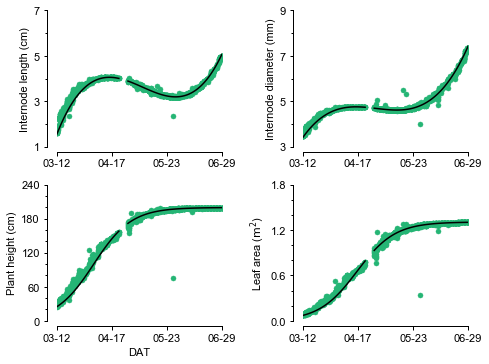

In [99]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*2.2)))
grid = plt.GridSpec(2, 2)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(pg_pred_df.index, pg_pred_df['pred_node_len'], 'o', ms=5, mew=0.5, c=cmap[3])
ax1.plot(pg_pred_df.index, pg_pred_df['pred_node_dia'], 'o', ms=5, mew=0.5, c=cmap[3])
ax2.plot(pg_pred_df.index, pg_pred_df['pred_plant_h'], 'o', ms=5, mew=0.5, c=cmap[3])
ax3.plot(pg_pred_df.index, pg_pred_df['pred_leaf_area'], 'o', ms=5, mew=0.5, c=cmap[3])

ax0.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_node_len'].resample('D').mean(), '-', c='k')
ax1.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_node_dia'].resample('D').mean(), '-', c='k')
ax2.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_plant_h'].resample('D').mean(), '-', c='k')
ax3.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_leaf_area'].resample('D').mean(), '-', c='k')

ax0.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax0.xaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_minor_locator(LinearLocator(7))
ax0.set_ybound(1, 7)
ax1.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.xaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_minor_locator(LinearLocator(7))
ax1.set_ybound(3, 9)
ax2.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.xaxis.set_major_locator(LinearLocator(4))
ax2.yaxis.set_major_locator(LinearLocator(5))
ax2.yaxis.set_minor_locator(LinearLocator(13))
ax2.set_ybound(0, 240)
ax3.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax3.xaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_minor_locator(LinearLocator(10))
ax3.set_ybound(0, 1.8)

ax0.set_ylabel('Internode length (cm)')
ax1.set_ylabel('Internode diameter (mm)')
ax2.set_xlabel('DAT')
ax2.set_ylabel('Plant height (cm)')
ax3.set_ylabel('Leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig14.svg', transparent=True, format='svg')
plt.show()

#  Fig. 14-2

In [100]:
pg_pred_df = pd.read_csv('./results/model_output/pg_transfer_pred_result.csv', index_col='Unnamed: 0')

In [101]:
pg_pred_df = pg_pred_df.sort_index()

In [102]:
pg_pred_df.index = pd.DatetimeIndex(pg_pred_df.index)

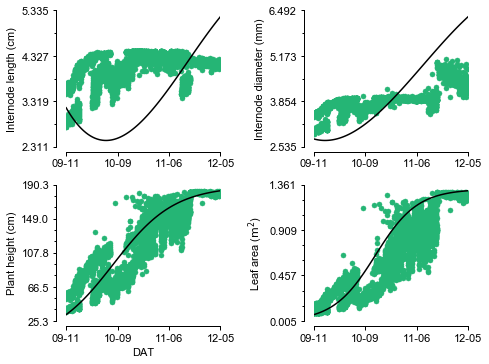

In [104]:
fig = plt.figure(figsize=((8/2.54*2.2), (6/2.54*2.2)))
grid = plt.GridSpec(2, 2)

ax0 = plt.subplot(grid[0])
ax1 = plt.subplot(grid[1])
ax2 = plt.subplot(grid[2])
ax3 = plt.subplot(grid[3])

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 10))
ax0.spines['bottom'].set_position(('outward', 5))
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_position(('outward', 10))
ax1.spines['bottom'].set_position(('outward', 5))
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_position(('outward', 10))
ax2.spines['bottom'].set_position(('outward', 5))
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_position(('outward', 10))
ax3.spines['bottom'].set_position(('outward', 5))

ax0.plot(pg_pred_df.index, pg_pred_df['pred_node_len'], 'o', ms=5, mew=0.5, c=cmap[3])
ax1.plot(pg_pred_df.index, pg_pred_df['pred_node_dia'], 'o', ms=5, mew=0.5, c=cmap[3])
ax2.plot(pg_pred_df.index, pg_pred_df['pred_plant_h'], 'o', ms=5, mew=0.5, c=cmap[3])
ax3.plot(pg_pred_df.index, pg_pred_df['pred_leaf_area'], 'o', ms=5, mew=0.5, c=cmap[3])

ax0.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_node_len'].resample('D').mean(), '-', c='k')
ax1.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_node_dia'].resample('D').mean(), '-', c='k')
ax2.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_plant_h'].resample('D').mean(), '-', c='k')
ax3.plot(pg_pred_df.resample('D').mean().index, pg_pred_df['label_leaf_area'].resample('D').mean(), '-', c='k')

ax0.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax0.xaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_major_locator(LinearLocator(4))
ax0.yaxis.set_minor_locator(LinearLocator(7))
# ax0.set_ybound(1, 7)
ax1.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.xaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_major_locator(LinearLocator(4))
ax1.yaxis.set_minor_locator(LinearLocator(7))
# ax1.set_ybound(3, 9)
ax2.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.xaxis.set_major_locator(LinearLocator(4))
ax2.yaxis.set_major_locator(LinearLocator(5))
ax2.yaxis.set_minor_locator(LinearLocator(13))
# ax2.set_ybound(0, 240)
ax3.set_xbound(pg_pred_df.index[0], pg_pred_df.index[-1])
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax3.xaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_major_locator(LinearLocator(4))
ax3.yaxis.set_minor_locator(LinearLocator(10))
# ax3.set_ybound(0, 1.8)

ax0.set_ylabel('Internode length (cm)')
ax1.set_ylabel('Internode diameter (mm)')
ax2.set_xlabel('DAT')
ax2.set_ylabel('Plant height (cm)')
ax3.set_ylabel('Leaf area ($m^2$)')

fig.tight_layout()
fig.savefig('./figures/Fig14.svg', transparent=True, format='svg')
plt.show()